# P02: RSSM 동역학 모델 구축

합성 픽셀 궤적에 대해 GRU, MDN-RNN, RSSM 동역학 모델을 학습시키고 비교합니다. 이 노트북의 목적은 순위를 매기는 것이 아니라 비교입니다. GRU는 가장 단순한 기준선이고, MDN-RNN은 예측 불확실성을 추가하며, RSSM은 월드모델 스타일 롤아웃을 위한 잠재 확률 상태를 도입합니다.

**선행 조건**: P01(`vae_encoder.pt`)이 있으면 사용합니다. 없으면 무작위로 초기화된 인코더로 대체되어 노트북은 여전히 실행되지만, 롤아웃 비교는 사전학습된 체크포인트가 있어야만 의미가 있습니다. 이 노트북은 동역학 모델들을 학습시키고 RSSM을 `rssm.pt`로 저장해 P03과 P04에 전달합니다.

> Notebook 원본: [p02_rssm_dynamics.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/ko/projects/p02_rssm_dynamics.ipynb)

In [1]:
%%bash
# Install dependencies for a fresh environment.
if command -v rocm-smi >/dev/null || [ -d /opt/rocm ]; then
  pip install torch torchvision --index-url https://download.pytorch.org/whl/rocm7.2
  pip install matplotlib numpy
else
  pip install torch torchvision matplotlib numpy
fi


## 1. 준비

고정된 인코더, 합성 궤적, 잠재 데이터셋을 구성합니다.

In [2]:
import os
import math
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'
LOAD_DEVICE = torch.device('cpu') if USE_TPU else DEVICE


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer_step(optimizer)

LATENT_DIM = 32
HIDDEN_DIM = 128
ACTION_DIM = 1
N_TRAJ     = 200
T_STEPS    = 20
IMG_SIZE   = 64

print(f'Device: {DEVICE}')
if USE_TPU:
    print('TPU backend    : torch_xla')
print(f'LATENT_DIM={LATENT_DIM}, HIDDEN_DIM={HIDDEN_DIM}')

Device: cuda
LATENT_DIM=32, HIDDEN_DIM=128


준비가 끝났으니, P01의 인코더와 디코더를 재사용해 동역학 모델이 나머지 월드모델 스택과 같은 잠재 공간에서 동작하도록 합니다. `_load_vae_checkpoint`는 이 노트북의 `VAEEncoder` 클래스와 P01의 `Encoder` 사이에 있는 작은 이름 불일치(`fc_log_var` 대 `fc_var`)를 처리하지만, `vae_encoder.pt`가 있다면 내부 가중치는 동일합니다. 두 네트워크 모두 `.eval()`로 설정되고 모든 파라미터에 `requires_grad_(False)`가 적용됩니다. 인코더와 디코더는 이 노트북의 나머지 부분에서 고정되며, 픽셀과 잠재값을 서로 변환하는 데만 쓰일 뿐 아래의 동역학 학습으로 갱신되지 않습니다.

In [ ]:
# P01-compatible VAE encoder and decoder

class VAEEncoder(nn.Module):
    """Encode 64x64 RGB frames into latent mean and logvar."""
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.conv = nn.Sequential(
            nn.Conv2d(3,   32,  4, stride=2, padding=1),  # 64->32
            nn.ReLU(),
            nn.Conv2d(32,  64,  4, stride=2, padding=1),  # 32->16
            nn.ReLU(),
            nn.Conv2d(64,  128, 4, stride=2, padding=1),  # 16->8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),  # 8->4
            nn.ReLU(),
        )
        self.fc_mu  = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_var = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        h = self.conv(x).reshape(x.size(0), -1)
        return self.fc_mu(h), self.fc_var(h)

    def encode(self, x):
        """Reparameterized sample from q(z|x)."""
        mu, logvar = self.forward(x)
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)


class VAEDecoder(nn.Module):
    """Mirror decoder: latent_dim -> 64x64 RGB in [0,1]."""
    def __init__(self, latent_dim=32):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,  3,   4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).reshape(-1, 256, 4, 4)
        return self.deconv(h)


encoder = VAEEncoder(LATENT_DIM).to(DEVICE)
decoder = VAEDecoder(LATENT_DIM).to(DEVICE)

def _load_vae_checkpoint(path):
    ckpt = torch.load(path, map_location=DEVICE)
    if 'model_state_dict' in ckpt:
        state = ckpt['model_state_dict']
        enc_state = {
            k.removeprefix('encoder.').replace('fc_log_var', 'fc_var'): v
            for k, v in state.items()
            if k.startswith('encoder.')
        }
        dec_state = {
            k.removeprefix('decoder.'): v
            for k, v in state.items()
            if k.startswith('decoder.')
        }
        encoder.load_state_dict(enc_state)
        decoder.load_state_dict(dec_state)
        return True
    if 'encoder' in ckpt and 'decoder' in ckpt:
        encoder.load_state_dict(ckpt['encoder'])
        decoder.load_state_dict(ckpt['decoder'])
        return True
    raise KeyError(f'Unrecognized checkpoint format: {list(ckpt.keys())[:10]}')

ckpt_path = Path('vae_encoder.pt')
try:
    _load_vae_checkpoint(ckpt_path)
    print(f'Loaded VAE weights from {ckpt_path}')
except Exception as e:
    print(f'Could not load VAE checkpoint from {ckpt_path} ({e}); using random init.')

VAE_CHECKPOINT_PATH = ckpt_path

encoder.eval()
decoder.eval()
for p in list(encoder.parameters()) + list(decoder.parameters()):
    p.requires_grad_(False)

print(f'Encoder params: {sum(p.numel() for p in encoder.parameters()):,}')
print(f'Decoder params: {sum(p.numel() for p in decoder.parameters()):,}')

Loaded VAE weights from vae_encoder.pt
Encoder params: 952,352
Decoder params: 825,059


다음으로 합성 궤적을 생성합니다. 이 롤아웃들이 시퀀스 모델의 지도 신호가 됩니다. 각 궤적은 고정된 속도 `(vx, vy)`와 스텝마다 더해지는 작은 노이즈로 화면을 가로질러 이동하는 색상 있는 사각형이며, 매 스텝마다 이진 `action`이 함께 기록됩니다(현재는 장식적입니다. 기록되어 아래 모든 모델에 입력되지만, 사각형의 움직임은 이 값에 의존하지 않습니다). 이렇게 하면 비교의 초점이, 복잡한 동작 조건부 규칙을 발견할 수 있는지가 아니라, 단순하고 거의 결정론적인 동역학에 대해 GRU, MDN-RNN, RSSM이 *불확실성*을 모델링하는 방식이 어떻게 다른지에 맞춰집니다.

In [4]:
# Generate synthetic trajectory data.

def make_trajectory(T=20, img_size=64, seed=None):
    rng = np.random.RandomState(seed)
    color = rng.rand(3).astype(np.float32)
    w  = rng.randint(10, 20)
    h  = rng.randint(10, 20)
    x  = float(rng.randint(0, img_size - w))
    y  = float(rng.randint(0, img_size - h))
    vx = float(rng.randint(-3, 4))
    vy = float(rng.randint(-3, 4))
    frames  = []
    actions = []
    for _ in range(T):
        img = np.zeros((img_size, img_size, 3), dtype=np.float32)
        x1, y1 = int(np.clip(x, 0, img_size - w)), int(np.clip(y, 0, img_size - h))
        img[y1:y1 + h, x1:x1 + w] = color
        frames.append(img)
        actions.append(int(rng.randint(0, 2)))
        x = float(np.clip(x + vx + rng.uniform(-1, 1), 0, img_size - w))
        y = float(np.clip(y + vy + rng.uniform(-1, 1), 0, img_size - h))
    obs = torch.from_numpy(np.stack(frames)).permute(0, 3, 1, 2)  # [T,3,H,W]
    act = torch.tensor(actions, dtype=torch.float32)               # [T]
    return {'obs': obs, 'actions': act}


print('Generating 200 synthetic trajectories...')
trajectories = [make_trajectory(T=T_STEPS, img_size=IMG_SIZE, seed=i) for i in range(N_TRAJ)]
print(f"obs shape per trajectory:     {trajectories[0]['obs'].shape}")
print(f"actions shape per trajectory: {trajectories[0]['actions'].shape}")

Generating 200 synthetic trajectories...
obs shape per trajectory:     torch.Size([20, 3, 64, 64])
actions shape per trajectory: torch.Size([20])


궤적이 만들어지면, 각 관측을 z로 인코딩해 노트북의 나머지 부분이 원본 픽셀이 아니라 잠재 시퀀스에 대한 동역학을 학습하도록 합니다. `encoder.encode(obs)`는 P01의 `reparameterize`에서 나온 *샘플링* 경로(`mu + std * epsilon`)를 호출하며, 평균만 쓰는 것이 아닙니다. 그래서 여기서의 각 `z_t`는 이미 VAE의 사후분포가 해당 프레임에 부여하는 약간의 확률성을 담고 있습니다. 이는 아래 RSSM 절을 이해하는 데 중요합니다. `z_seq`는 RSSM 자신의 사후분포 네트워크가 재현하도록 학습하는 *사후분포 목표*를 제공합니다.

In [5]:
# Encode observations into latent sequences z [N, T, 32]

print('Encoding observations...')
latent_list = []
with torch.no_grad():
    for traj in trajectories:
        obs = traj['obs'].to(DEVICE)      # [T,3,H,W]
        z   = encoder.encode(obs)         # [T, latent_dim]
        latent_list.append(z.cpu())

Z_all = torch.stack(latent_list, dim=0)                                     # [N,T,32]
A_all = torch.stack([t['actions'] for t in trajectories], dim=0)            # [N,T]

# Train/test split
N_TRAIN = 180
Z_train, A_train = Z_all[:N_TRAIN].to(DEVICE), A_all[:N_TRAIN].to(DEVICE)
Z_test,  A_test  = Z_all[N_TRAIN:].to(DEVICE), A_all[N_TRAIN:].to(DEVICE)

print(f'Z_all shape: {Z_all.shape}  (N, T, latent_dim)')
print(f'Train: {N_TRAIN} trajectories | Test: {N_TRAJ - N_TRAIN} trajectories')

Encoding observations...
Z_all shape: torch.Size([200, 20, 32])  (N, T, latent_dim)
Train: 180 trajectories | Test: 20 trajectories


## 2. 동역학 모델

단순한 GRU 기준선에서 시작해, 혼합 밀도 출력과 RSSM 잠재 상태를 차례로 추가합니다. 아래 세 클래스는 모두 [잠재 동역학](../lectures/lecture-02-encode-and-dynamics/02-dynamics)에서 다룬 모델을 구현합니다. 입력 `(z_t, a_t)`도 같고, 목표(`z_{t+1}` 예측)도 같지만, 불확실성을 다루는 방식이 서로 다릅니다. 세 `forward` 메서드를 나란히 읽어보는 것이 강의에서 수식으로만 설명한 실제 코드 수준의 차이를 가장 빠르게 확인하는 방법입니다.

In [6]:
class GRUDynamics(nn.Module):
    """GRU with hidden_dim=128, input=(latent_dim+action_dim), output=latent_dim.
    Takes (z_t, a_t) -> h_{t+1} -> predicts z_{t+1}.
    """
    def __init__(self, latent_dim=32, action_dim=1, hidden_dim=128):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gru    = nn.GRUCell(latent_dim + action_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z_seq, a_seq):
        """z_seq [B,T,D], a_seq [B,T] -> pred_z [B,T-1,D] for steps 1..T."""
        B, T, _ = z_seq.shape
        h = torch.zeros(B, self.hidden_dim, device=z_seq.device)
        preds = []
        for t in range(T - 1):
            inp = torch.cat([z_seq[:, t], a_seq[:, t].unsqueeze(-1)], dim=-1)
            h   = self.gru(inp, h)
            preds.append(self.output(h))
        return torch.stack(preds, dim=1)  # [B, T-1, D]

    def rollout(self, z0, a_seq):
        """Open-loop rollout from z0 [1,D] for len(a_seq) steps.
        Returns [1, steps+1, D] (includes z0).
        """
        z = z0
        h = torch.zeros(1, self.hidden_dim, device=z0.device)
        zs = [z]
        for a in a_seq:
            inp = torch.cat([z, a.view(1, 1)], dim=-1)
            h   = self.gru(inp, h)
            z   = self.output(h)
            zs.append(z)
        return torch.stack(zs, dim=1)  # [1, steps+1, D]


gru_model = GRUDynamics(LATENT_DIM, ACTION_DIM, HIDDEN_DIM).to(DEVICE)
print(f'GRUDynamics params: {sum(p.numel() for p in gru_model.parameters()):,}')

GRUDynamics params: 66,720


일반 GRU 기준선을 마련했으니, 단일 예측이 포착할 수 없는 다봉 불확실성을 모델링하기 위해 MDN-RNN을 추가합니다. `GRUDynamics.forward`는 강의의 $\mathbf{z}_{t+1} = \text{GRU}(\mathbf{z}_t, \mathbf{a}_t)$를 그대로 코드로 옮긴 것입니다. `torch.cat([z_seq[:, t], a_seq[:, t].unsqueeze(-1)], dim=-1)`는 결합된 `(z_t, a_t)` 입력을 만들고, `self.gru(inp, h)`는 게이트 업데이트 자체입니다(PyTorch 내장 `GRUCell`이 강의의 설명 상자에 나온 리셋/업데이트 게이트 메커니즘을 내부적으로 구현합니다). `self.output(h)`는 은닉 상태를 예측된 `z_{t+1}`로 바꾸는 선형 출력층입니다. 이 클래스 어디에도 샘플링 단계는 없습니다. 같은 `(z_t, a_t, h_{t-1})`이 주어지면 GRU는 항상 같은 `z_{t+1}`을 만들어내며, 이것이 바로 강의가 지적한 "결정론적 출력"이라는 한계입니다.

`MDNRNN`은 이 단일 선형 출력층을 `mdn_head`로 대체합니다. 이는 혼합 성분 `k`마다 세 그룹의 출력을 만드는 선형층입니다: `logits`(소프트맥스 이전 값으로, 혼합 가중치 $\pi_k$가 됩니다), `mu`(성분 평균 $\mu_k$), `log_s`(성분별 로그분산으로, P01의 `log_var`와 대응됩니다). `_split`은 헤드의 평탄한 출력 텐서에서 이 세 그룹을 잘라냅니다. `mdn_loss`는 강의에서 다룬 $p(\mathbf{z}_{t+1} \mid \mathbf{z}_t, \mathbf{a}_t) = \sum_k \pi_k \mathcal{N}(\mathbf{z}_{t+1}; \mu_k, \sigma_k^2)$라는 가우시안 혼합에 대한 음의 로그가능도입니다. `log_p`는 각 성분의 로그밀도를 계산합니다(32개 잠재 차원이 독립이라고 가정해 합산한 가우시안 로그가능도 공식입니다). `log_pi`는 로그소프트맥스로 원 로짓을 $\log \pi_k$로 정규화합니다. `torch.logsumexp(log_pi + log_p, dim=-1)`는 이 둘을 결합해 $\log \sum_k \pi_k \mathcal{N}(\ldots)$를 만듭니다. 지수를 취해 직접 더하지 않고 로그 공간에서 계산하는 이유는 수치 안정성 때문입니다(큰 로그밀도값에서는 오버플로 위험이 있습니다). 부호를 바꾸고 평균을 내면 최소화할 손실이 됩니다.

롤아웃 시점에는 `MDNRNN.rollout`이 혼합분포에서 샘플링하지 않습니다. 대신 결정론적으로 가중치가 가장 큰 성분(`lg[0].argmax()`)을 골라 그 평균을 사용합니다. 즉 MDN-RNN의 *학습* 목적함수는 다봉성을 포착하지만, 이 노트북 뒤쪽에서 보여주는 *롤아웃*은 항상 가장 가능성 높은 하나의 분기만 따라가므로 그 다봉성을 실제로 활용하지는 않습니다.

In [7]:
class MDNRNN(nn.Module):
    """GRU + MDN head predicting a mixture of 3 Gaussians over z_{t+1}.
    MDN loss: negative log-likelihood of the mixture.
    """
    def __init__(self, latent_dim=32, action_dim=1, hidden_dim=128, n_mix=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.n_mix  = n_mix
        self.gru    = nn.GRUCell(latent_dim + action_dim, hidden_dim)
        # logits (K), mu (K*D), log_sigma (K*D)
        self.mdn_head = nn.Linear(hidden_dim, n_mix + 2 * n_mix * latent_dim)

    def _split(self, out):
        K, D = self.n_mix, self.latent_dim
        logits = out[..., :K]
        mu     = out[..., K:K + K * D].reshape(*out.shape[:-1], K, D)
        log_s  = out[..., K + K * D:].reshape(*out.shape[:-1], K, D)
        return logits, mu, log_s

    def forward(self, z_seq, a_seq):
        """Returns (logits, mu, log_sigma) each [B, T-1, ...] for MDN loss."""
        B, T, _ = z_seq.shape
        h = torch.zeros(B, self.hidden_dim, device=z_seq.device)
        all_logits, all_mu, all_ls = [], [], []
        for t in range(T - 1):
            inp = torch.cat([z_seq[:, t], a_seq[:, t].unsqueeze(-1)], dim=-1)
            h   = self.gru(inp, h)
            lg, mu, ls = self._split(self.mdn_head(h))
            all_logits.append(lg)
            all_mu.append(mu)
            all_ls.append(ls)
        return (
            torch.stack(all_logits, dim=1),
            torch.stack(all_mu,     dim=1),
            torch.stack(all_ls,     dim=1),
        )

    def mdn_loss(self, logits, mu, log_sigma, target):
        """Negative log-likelihood of mixture.
        logits [B,T,K], mu [B,T,K,D], log_sigma [B,T,K,D], target [B,T,D].
        """
        B, T, K, D = mu.shape
        tgt = target.unsqueeze(2).expand_as(mu)  # [B,T,K,D]
        sigma = log_sigma.exp().clamp(min=1e-4)
        log_p = -0.5 * (((tgt - mu) / sigma) ** 2 + 2 * log_sigma
                        + math.log(2 * math.pi))
        log_p  = log_p.sum(-1)                          # [B,T,K]
        log_pi = F.log_softmax(logits, dim=-1)          # [B,T,K]
        return -torch.logsumexp(log_pi + log_p, dim=-1).mean()

    def rollout(self, z0, a_seq):
        """Open-loop rollout using the most likely mixture component.
        Returns [1, steps+1, D].
        """
        z  = z0
        h  = torch.zeros(1, self.hidden_dim, device=z0.device)
        zs = [z]
        for a in a_seq:
            inp = torch.cat([z, a.view(1, 1)], dim=-1)
            h   = self.gru(inp, h)
            lg, mu, _ = self._split(self.mdn_head(h))
            k = lg[0].argmax().item()
            z = mu[0, k].unsqueeze(0)   # [1, D]
            zs.append(z)
        return torch.stack(zs, dim=1)


mdn_model = MDNRNN(LATENT_DIM, ACTION_DIM, HIDDEN_DIM, n_mix=3).to(DEVICE)
print(f'MDNRNN params: {sum(p.numel() for p in mdn_model.parameters()):,}')

MDNRNN params: 87,747


두 기준선을 정의했으니, 이들과 비교할 구조화된 잠재 상태 모델로 RSSM을 소개합니다. `RSSM.forward`는 [잠재 동역학 강의의 RSSM 절](../lectures/lecture-02-encode-and-dynamics/02-dynamics#rssm-separating-deterministic-and-stochastic-components)에 나온 세 핵심 수식을 하나의 `for t in range(T)` 루프 안에서 구현합니다.

- `h = self.gru(inp, h)`는 결정론적 업데이트 $\mathbf{h}_t = f_\phi(\mathbf{h}_{t-1}, \mathbf{z}_{t-1}, \mathbf{a}_{t-1})$입니다. 여기서 `inp` 우변의 `z`는 이전 스텝에서 *샘플링된* 잠재값으로, 이전 루프 반복에서 넘어온 것입니다(`t=0`에서는 0으로 초기화됩니다).
- `pr = self.prior_net(h)`를 `mu_pr, lv_pr`로 나눈 것은 사전분포 $\mathbf{z}_t \sim p_\phi(\mathbf{z}_t \mid \mathbf{h}_t)$입니다. `h`에만 의존하며 현재 관측에는 접근하지 못하는데, 이는 강의에서 사전분포를 순수 상상(imagination)에 쓰이는 분기로 설명한 것과 일치합니다.
- `po = self.post_net(torch.cat([h, z_seq[:, t]], dim=-1))`을 `mu_po, lv_po`로 나눈 것은 사후분포 $\mathbf{z}_t \sim q_\phi(\mathbf{z}_t \mid \mathbf{h}_t, \mathbf{o}_t)$입니다. 여기에는 이 궤적에서 이 스텝의 실제 인코딩된 관측인 `z_seq[:, t]`가 추가로 들어가는데, 이것이 강의에서 말한 "실제 관측으로부터의 보정"입니다. `self._rsample(mu_po, lv_po)`는 재귀를 이어가는(다음 스텝의 `inp`로 쓰이는) 동시에 아래 KL 항에서 사전분포와 비교되는 `z` 값을 뽑습니다.

`forward`의 KL 항 `kl = 0.5 * (lv_pr - lv_po + (lv_po.exp() + (mu_po - mu_pr)**2) / lv_pr.exp().clamp(min=1e-4) - 1)`은 (표준정규가 아닌) 일반적인 두 대각 가우시안 사이의 닫힌 형태 KL 발산 $D_{KL}(q_\phi(\mathbf{z}_t \mid \mathbf{h}_t, \mathbf{o}_t) \,\|\, p_\phi(\mathbf{z}_t \mid \mathbf{h}_t))$입니다. 이는 P01에서 쓴 것과 같은 가우시안 KL 공식을 더 일반화한 형태로, "사후분포 대 표준정규 사전분포"에서 "사후분포 대 *학습된* 사전분포 네트워크"로 확장한 것이며, 이것이 바로 RSSM의 KL 항을 단순한 VAE와 구분 짓는 지점입니다. 이 KL을 최소화하면 (`o_t`에 접근하지 못하는) 사전분포가 (접근하는) 사후분포와 일치하도록 끌어당겨지므로, 롤아웃 시점에 사전분포만 사용할 수 있을 때도 사후분포가 말했을 법한 것을 근사하도록 학습됩니다.

`RSSM.rollout`은 `post_net`은 전혀 쓰지 않고 `prior_net`만 사용하며, 샘플링 대신 사전분포의 평균(`mu`)을 그대로 씁니다. 이는 강의에서 상상을 "실제 관측이 전혀 관여하지 않는 사전분포 전용 롤아웃"으로 설명한 것과 정확히 일치합니다.

In [8]:
class RSSM(nn.Module):
    """Recurrent State Space Model.
    Deterministic path: h_t = GRU(h_{t-1}, z_{t-1}, a_{t-1})
    Stochastic prior:   z_t ~ N(mu_prior(h_t), sigma_prior(h_t))
    Stochastic posterior: z_t ~ N(mu_post(h_t, o_t), sigma_post(h_t, o_t))
    Training: ELBO = reconstruction + KL(posterior || prior)
    hidden_dim=128, latent_dim=32
    """
    def __init__(self, latent_dim=32, action_dim=1, hidden_dim=128):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # Deterministic recurrence
        self.gru = nn.GRUCell(latent_dim + action_dim, hidden_dim)

        # Prior: h_t -> (mu, logvar)
        self.prior_net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )

        # Posterior: (h_t, o_t) -> (mu, logvar),  o_t = encoded observation
        self.post_net = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, 2 * latent_dim),
        )

        # Reconstruction head: z -> predicted z (latent reconstruction target)
        self.recon = nn.Linear(latent_dim, latent_dim)

    def _rsample(self, mu, logvar):
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)

    def forward(self, z_seq, a_seq):
        """Compute ELBO over a full trajectory.
        z_seq [B,T,D], a_seq [B,T].
        Returns scalar ELBO loss.
        """
        B, T, D = z_seq.shape
        h = torch.zeros(B, self.hidden_dim, device=z_seq.device)
        z = torch.zeros(B, D, device=z_seq.device)
        recon_loss = z_seq.new_zeros(())
        kl_loss    = z_seq.new_zeros(())
        for t in range(T):
            inp = torch.cat([z, a_seq[:, t].unsqueeze(-1)], dim=-1)
            h   = self.gru(inp, h)

            # Prior
            pr   = self.prior_net(h)
            mu_pr, lv_pr = pr.chunk(2, dim=-1)

            # Posterior conditioned on observed latent o_t = z_seq[:, t]
            po   = self.post_net(torch.cat([h, z_seq[:, t]], dim=-1))
            mu_po, lv_po = po.chunk(2, dim=-1)

            z = self._rsample(mu_po, lv_po)

            # Reconstruction: predict the observation latent
            recon_loss = recon_loss + F.mse_loss(self.recon(z), z_seq[:, t])

            # KL(posterior || prior)
            kl = 0.5 * (
                lv_pr - lv_po
                + (lv_po.exp() + (mu_po - mu_pr) ** 2) / lv_pr.exp().clamp(min=1e-4)
                - 1
            )
            kl_loss = kl_loss + kl.mean()

        return (recon_loss + kl_loss) / T

    def rollout(self, z0, a_seq):
        """Open-loop rollout using the prior only (no observations).
        Returns [1, steps+1, D].
        """
        z  = z0
        h  = torch.zeros(1, self.hidden_dim, device=z0.device)
        zs = [z]
        for a in a_seq:
            inp = torch.cat([z, a.view(1, 1)], dim=-1)
            h   = self.gru(inp, h)
            pr  = self.prior_net(h)
            mu, _ = pr.chunk(2, dim=-1)
            z  = mu  # use prior mean for deterministic rollout
            zs.append(z)
        return torch.stack(zs, dim=1)


rssm_model = RSSM(LATENT_DIM, ACTION_DIM, HIDDEN_DIM).to(DEVICE)
print(f'RSSM params: {sum(p.numel() for p in rssm_model.parameters()):,}')

RSSM params: 117,280


**강의 예시 직접 확인해보기**: 강의에서는 단순화된(게이트 없는 선형) RSSM 전이 한 스텝을 손으로 계산해 $\mathbf{h}_t = [0.60, 0.20]$, $\mu_{\text{pr}} = 0.40$, $z_t = 0.50$을 얻었습니다. 아래 셀은 같은 숫자와 가중치로 같은 계산을 그대로 실행합니다. 다만 위의 `RSSM` 클래스는 의도적으로 쓰지 않는다는 점에 유의하세요(그 클래스는 내부적으로 진짜 `GRUCell`과 다층 사전 확률 네트워크를 쓰므로 수치가 이 단순화 버전과 맞지 않습니다). 오직 공식의 유도 자체가 맞는지만 검증하는 셀입니다.

In [ ]:
# 강의의 손 계산 예시와 일치하는 단순화된 단일 스텝 전이(실제 RSSM 클래스 아님).
h_prev = torch.tensor([0.0, 0.0])
z_prev = torch.tensor(0.50)
a_prev = torch.tensor(1.0)

w_z = torch.tensor([0.4, 0.2])
w_a = torch.tensor([0.3, 0.1])
b_h = torch.tensor([0.1, 0.0])
h_t = w_z * z_prev + w_a * a_prev + b_h
print(f'h_t = {h_t.tolist()}')
assert torch.allclose(h_t, torch.tensor([0.60, 0.20]), atol=1e-6)

w_mu = torch.tensor([0.5, 0.5])
sigma_pr = 0.20
mu_pr = (w_mu * h_t).sum()
print(f'mu_pr = {mu_pr.item():.2f}')
assert abs(mu_pr.item() - 0.40) < 1e-6

eps = torch.tensor(0.50)
z_t = mu_pr + sigma_pr * eps
print(f'z_t = {z_t.item():.2f}')
assert abs(z_t.item() - 0.50) < 1e-6


## 3. 학습

세 모델 모두 180개 학습 궤적에 대해 Adam(lr=1e-3)으로 20 에폭 동안 학습됩니다.
손실 함수:
- GRU: 예측된 z와 실제 z 사이의 MSE
- MDN-RNN: 가우시안 혼합의 음의 로그가능도
- RSSM: ELBO = z의 MSE 재구성 + KL 발산

In [9]:
EPOCHS = 20
BATCH  = 32
LR     = 1e-3

opt_gru  = torch.optim.Adam(gru_model.parameters(),  lr=LR)
opt_mdn  = torch.optim.Adam(mdn_model.parameters(),  lr=LR)
opt_rssm = torch.optim.Adam(rssm_model.parameters(), lr=LR)


def run_epoch(model, optimizer, Z, A, loss_fn):
    model.train()
    N   = Z.shape[0]
    idx = torch.randperm(N)
    total, nb = 0.0, 0
    for s in range(0, N, BATCH):
        bi  = idx[s:s + BATCH]
        zb, ab = Z[bi], A[bi]
        optimizer.zero_grad()
        loss = loss_fn(model, zb, ab)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item(); nb += 1
    return total / nb


def gru_loss(m, zb, ab):
    return F.mse_loss(m(zb, ab), zb[:, 1:])


def mdn_loss_fn(m, zb, ab):
    logits, mu, ls = m(zb, ab)
    return m.mdn_loss(logits, mu, ls, zb[:, 1:])


def rssm_loss(m, zb, ab):
    return m(zb, ab)


losses_gru, losses_mdn, losses_rssm = [], [], []

print(f'Training 3 models for {EPOCHS} epochs...')
for epoch in range(1, EPOCHS + 1):
    lg = run_epoch(gru_model,  opt_gru,  Z_train, A_train, gru_loss)
    lm = run_epoch(mdn_model,  opt_mdn,  Z_train, A_train, mdn_loss_fn)
    lr = run_epoch(rssm_model, opt_rssm, Z_train, A_train, rssm_loss)
    losses_gru.append(lg)
    losses_mdn.append(lm)
    losses_rssm.append(lr)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | GRU: {lg:.4f} | MDN-RNN: {lm:.4f} | RSSM: {lr:.4f}')

print('Training complete.')

Training 3 models for 20 epochs...
Epoch   1 | GRU: 0.9850 | MDN-RNN: 45.3777 | RSSM: 1.3083
Epoch   5 | GRU: 0.7552 | MDN-RNN: 40.3882 | RSSM: 0.8528
Epoch  10 | GRU: 0.7077 | MDN-RNN: 37.2091 | RSSM: 0.7898
Epoch  15 | GRU: 0.6934 | MDN-RNN: 36.0025 | RSSM: 0.7589
Epoch  20 | GRU: 0.6852 | MDN-RNN: 35.4053 | RSSM: 0.7324
Training complete.


`run_epoch`는 세 모델 모두가 공유하는 학습 루프입니다. 표준적인 미니배치 SGD에 `clip_grad_norm_(model.parameters(), 1.0)`을 더해 그래디언트 폭주를 막는데, 순환 모델은 여기서 쓰는 20스텝짜리 짧은 시퀀스에서도 특히 이 문제에 취약합니다. 세 개의 `*_loss` 래퍼 함수(`gru_loss`, `mdn_loss_fn`, `rssm_loss`)는 각 모델 고유의 손실 계산을 `run_epoch`가 기대하는 동일한 `loss_fn(model, zb, ab)` 시그니처에 맞춰주므로, 같은 학습 루프가 로직을 중복하지 않고도 세 모델 모두를 구동할 수 있습니다.

`RSSM.forward`(`rssm_loss`가 사용)는 원본 픽셀이 아니라 `self.recon(z)`를 통해 *잠재값* `z_seq[:, t]`를 재구성한다는 점에 유의하세요. 이는 이 노트북에 특화된 단순화입니다. 강의의 RSSM은 관측 $o_t \sim p(o_t \mid h_t, z_t)$를 직접 재구성하지만, 여기서 `z_seq`는 이미 고정된 P01 인코더의 출력이므로, 이를 재구성하는 것은 한 단계 건너뛴 픽셀 재구성의 대리 지표입니다. 세 손실은 서로 비교 가능한 수치 스케일에 있지 않습니다(MSE, 혼합 NLL, ELBO는 단위와 전형적인 크기가 다릅니다). 바로 그래서 다음 셀의 그래프는 원값이 아니라 각 곡선을 정규화한 뒤 형태를 비교합니다.

모델군을 정의했으니, 이제 에폭 일정을 정하고 세 동역학 변형을 나란히 학습시킵니다.

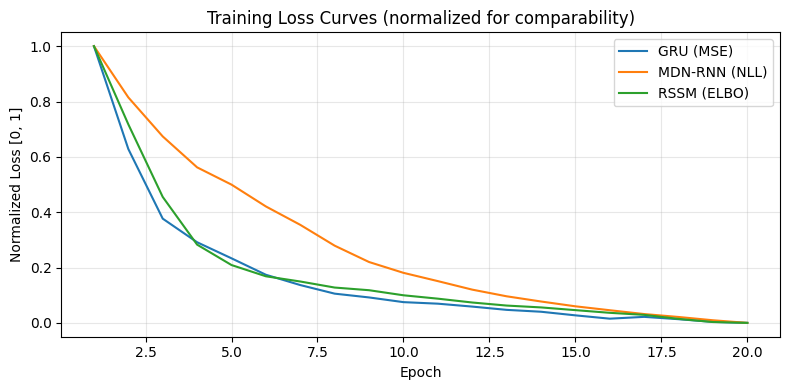

In [10]:
# Plot normalized training loss curves.

def norm01(curve):
    a = np.array(curve, dtype=np.float64)
    lo, hi = a.min(), a.max()
    return (a - lo) / (hi - lo + 1e-9)

fig, ax = plt.subplots(figsize=(8, 4))
xs = np.arange(1, EPOCHS + 1)
ax.plot(xs, norm01(losses_gru),  label='GRU (MSE)',     color='tab:blue')
ax.plot(xs, norm01(losses_mdn),  label='MDN-RNN (NLL)', color='tab:orange')
ax.plot(xs, norm01(losses_rssm), label='RSSM (ELBO)',   color='tab:green')
ax.set_xlabel('Epoch')
ax.set_ylabel('Normalized Loss [0, 1]')
ax.set_title('Training Loss Curves (normalized for comparability)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 롤아웃 비교

테스트 궤적의 첫 프레임에서 시작해, 각 모델이 미래 관측을 보지 않고 10스텝을 앞으로 굴립니다.
예측된 잠재값은 다시 픽셀 공간으로 디코딩되어 3행 10열 격자로 표시됩니다.

In [11]:
ROLLOUT_STEPS = 10

# Use the first test trajectory.
z_traj = Z_test[0]           # [T, D]
a_traj = A_test[0]           # [T]
z0     = z_traj[0].unsqueeze(0)        # [1, D]
a_seq  = a_traj[:ROLLOUT_STEPS]        # [10]

gru_model.eval()
mdn_model.eval()
rssm_model.eval()

with torch.no_grad():
    zs_gru  = gru_model.rollout(z0, a_seq).squeeze(0)    # [11, D]
    zs_mdn  = mdn_model.rollout(z0, a_seq).squeeze(0)
    zs_rssm = rssm_model.rollout(z0, a_seq).squeeze(0)

    def decode_seq(zs):
        """zs [S, D] -> numpy [S, H, W, 3] in [0,1]."""
        imgs = decoder(zs.to(DEVICE))  # [S, 3, H, W]
        return imgs.cpu().permute(0, 2, 3, 1).numpy()

    imgs_gru  = decode_seq(zs_gru)
    imgs_mdn  = decode_seq(zs_mdn)
    imgs_rssm = decode_seq(zs_rssm)
    imgs_gt   = decode_seq(z_traj[:ROLLOUT_STEPS + 1])   # ground truth

print(f'Decoded rollout shape (GRU): {imgs_gru.shape}  (steps+1, H, W, 3)')

Decoded rollout shape (GRU): (11, 64, 64, 3)  (steps+1, H, W, 3)


학습이 끝났으니, 롤아웃 평가로 넘어가 예측이 미래로 갈수록 오차가 어떻게 누적되는지 측정합니다. `ROLLOUT_STEPS = 10`개의 개방루프 스텝은, 각 모델에 첫 프레임 `z0`와 실제 동작 시퀀스만 주어지고, 이후의 모든 잠재값은 실제 관측의 추가 보정 없이 오직 자신의 이전 예측만으로 예측해야 한다는 뜻입니다. 이는 [L03의 STORM 논의](../lectures/lecture-03-architecture-patterns/01-architectures-rnn-transformer-diffusion#storms-key-improvement-single-token-stochastic-latent-variable)에서 설명하고 [L04](../lectures/lecture-04-evaluation-by-model/00-diagnostic-framework)에서 공식적으로 진단하는 **teacher forcing 격차**입니다. 학습에서는 매 스텝마다 실제 `z_seq`를 사용했지만, 이 평가는 각 모델이 스스로의 오차를 누적시키도록 강제합니다. 이것이 학습된 동역학이 실제로 상상 기반 계획에 쓸모 있는지를 판단하는 더 어렵고 더 현실적인 테스트입니다.

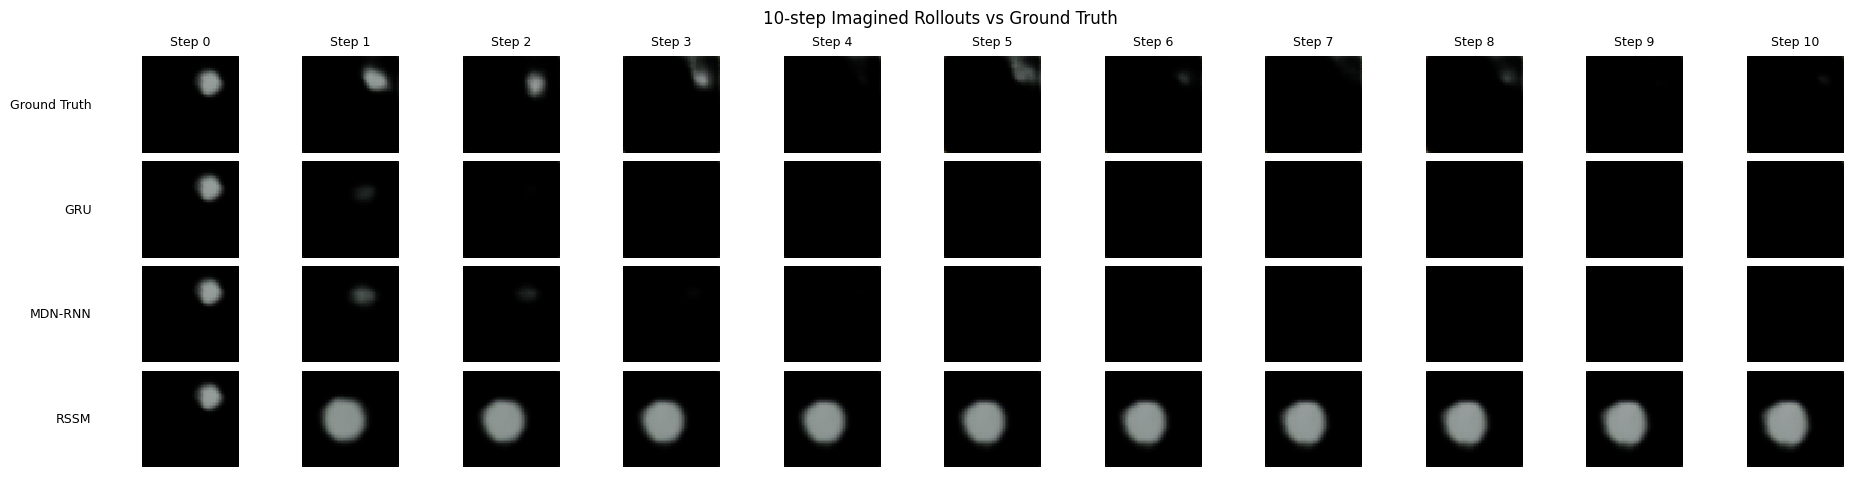

In [12]:
# Image grid: GT, GRU, MDN-RNN, RSSM.
N_COLS      = ROLLOUT_STEPS + 1
row_labels  = ['Ground Truth', 'GRU', 'MDN-RNN', 'RSSM']
row_imgs    = [imgs_gt, imgs_gru, imgs_mdn, imgs_rssm]

fig, axes = plt.subplots(
    4,
    N_COLS,
    figsize=(N_COLS * 1.7, 4.4),
    constrained_layout=True,
)
fig.patch.set_facecolor('white')
for r, (label, imgs) in enumerate(zip(row_labels, row_imgs)):
    for c in range(N_COLS):
        ax = axes[r, c]
        ax.imshow(np.clip(imgs[c], 0, 1), interpolation='nearest')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if c == 0:
            ax.set_ylabel(
                label,
                fontsize=9,
                rotation=0,
                labelpad=36,
                va='center',
                ha='right',
            )
        if r == 0:
            ax.set_title(f'Step {c}', fontsize=9, pad=8)
from IPython.display import display
fig.suptitle('10-step Imagined Rollouts vs Ground Truth', fontsize=12, y=1.05)
display(fig)
plt.close(fig)

이미지 격자는 시각적인 이야기를 보여줍니다. 다음 블록은 이를 정량적으로 보기 위해 스텝별 픽셀 MSE 곡선으로 바꿉니다. GRU는 불확실성을 표현하거나 보정할 메커니즘이 없으므로 가장 먼저, 가장 심하게 드리프트할 것으로 예상됩니다. MDN-RNN은 롤아웃이 결국 하나만 고르더라도 학습 중에는 여러 가능한 결과를 모델링하므로 다소 나은 결과를 보일 것입니다. RSSM은 사후분포가 실제 관측으로부터 추론했을 값과 일치하도록 명시적인 사전분포 네트워크를 학습했기 때문에, 이 거의 결정론적인 합성 데이터에서 가장 잘 버틸 것으로 예상됩니다.

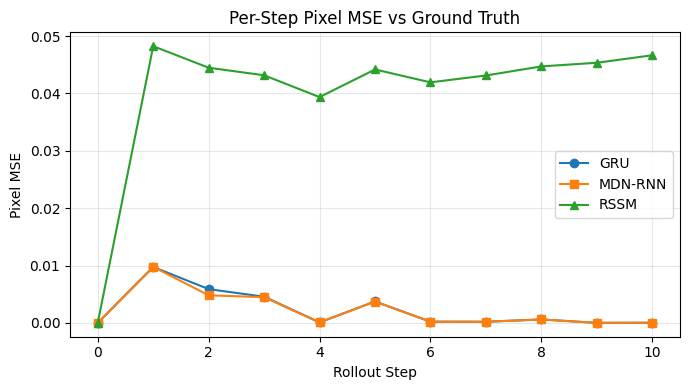

In [13]:
# Per-step pixel MSE vs ground truth.

def pixel_mse_per_step(pred, gt):
    return [float(((p - g) ** 2).mean()) for p, g in zip(pred, gt)]

mse_gru  = pixel_mse_per_step(imgs_gru,  imgs_gt)
mse_mdn  = pixel_mse_per_step(imgs_mdn,  imgs_gt)
mse_rssm = pixel_mse_per_step(imgs_rssm, imgs_gt)
steps_x  = list(range(N_COLS))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps_x, mse_gru,  marker='o', label='GRU',     color='tab:blue')
ax.plot(steps_x, mse_mdn,  marker='s', label='MDN-RNN', color='tab:orange')
ax.plot(steps_x, mse_rssm, marker='^', label='RSSM',    color='tab:green')
ax.set_xlabel('Rollout Step')
ax.set_ylabel('Pixel MSE')
ax.set_title('Per-Step Pixel MSE vs Ground Truth')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 1스텝 대 5스텝 예측 오차

홀드아웃 테스트 궤적에서 세 모델 모두에 대해 1~5스텝 지평선의 평균 잠재 공간 MSE를 계산합니다. `horizon_mse`는 모든 테스트 궤적에 걸쳐 창을 슬라이딩합니다(`for t0 in range(T - max_h)`). 각 창의 시작점에서 각 모델을 `max_h`스텝 앞으로 굴리고, 각 지평선에서 실제 잠재값과의 제곱 오차를 따로 누적합니다. 이는 L04의 진단 프레임워크가 장기 롤아웃 계층의 표준 근거로 꼽는 **오차-지평선 곡선**을 만들어냅니다. 곡선이 낮고 평평하게 유지되면 모델의 오차가 누적되지 않는다는 뜻이고, 지평선이 늘어남에 따라 곡선이 가파르게 오르면 스텝마다의 작은 실수가 눈덩이처럼 불어나고 있다는 뜻입니다. 이는 [L04](../lectures/lecture-04-evaluation-by-model/05-diffusion-drift#horizon-drift-the-universal-failure-mode-across-all-world-models)에서 모든 아키텍처에 대해 기록된 것과 같은 **지평선 드리프트(horizon drift)** 실패 모드입니다.

In [14]:
MAX_H = 5


def horizon_mse(model_rollout_fn, Z, A, max_h=5):
    """Average latent MSE at horizons 1..max_h on test set.
    model_rollout_fn(z0, a_seq) -> [1, steps+1, D]
    """
    N, T, D = Z.shape
    errs   = np.zeros(max_h)
    counts = np.zeros(max_h)
    with torch.no_grad():
        for i in range(N):
            for t0 in range(T - max_h):
                z0   = Z[i, t0].unsqueeze(0)          # [1, D]
                a_s  = A[i, t0:t0 + max_h]            # [max_h]
                zs   = model_rollout_fn(z0, a_s).squeeze(0)  # [max_h+1, D]
                for h in range(1, max_h + 1):
                    errs[h - 1]   += F.mse_loss(zs[h], Z[i, t0 + h]).item()
                    counts[h - 1] += 1
    return errs / counts


print('Computing horizon errors on test set...')
gru_model.eval(); mdn_model.eval(); rssm_model.eval()

err_gru  = horizon_mse(gru_model.rollout,  Z_test, A_test, MAX_H)
err_mdn  = horizon_mse(mdn_model.rollout,  Z_test, A_test, MAX_H)
err_rssm = horizon_mse(rssm_model.rollout, Z_test, A_test, MAX_H)

horizons = list(range(1, MAX_H + 1))
print('\nLatent MSE by horizon:')
print(f'{"Horizon":>8}  {"GRU":>10}  {"MDN-RNN":>10}  {"RSSM":>10}')
for h, (eg, em, er) in enumerate(zip(err_gru, err_mdn, err_rssm), start=1):
    print(f'{h:>8}  {eg:>10.4f}  {em:>10.4f}  {er:>10.4f}')

Computing horizon errors on test set...

Latent MSE by horizon:
 Horizon         GRU     MDN-RNN        RSSM
       1      0.7905      0.7861      1.1163
       2      0.7584      0.7532      1.2280
       3      0.7445      0.7395      1.3215
       4      0.7367      0.7317      1.3771
       5      0.7412      0.7375      1.4075


지평선 범위를 정했으니, 스텝별 예측 오차를 그래프로 그려 단기와 장기 지평선의 거동을 직접 비교할 수 있게 합니다. 이 그래프를 위의 정성적 롤아웃 격자와 함께 보는 것은 의도적입니다. 어떤 모델은 지평선 1에서의 오차가 낮으면서도(직후 예측은 정확하면서도) 지평선 5까지는 심하게 드리프트할 수 있는데, 단일 집계 수치가 아니라 다중 지평선 곡선만이 이를 드러냅니다.

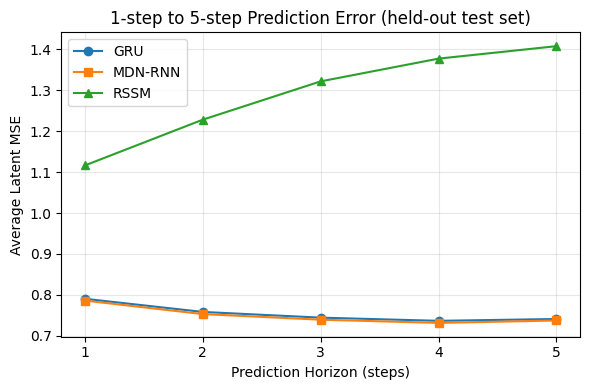

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(horizons, err_gru,  marker='o', label='GRU',     color='tab:blue')
ax.plot(horizons, err_mdn,  marker='s', label='MDN-RNN', color='tab:orange')
ax.plot(horizons, err_rssm, marker='^', label='RSSM',    color='tab:green')
ax.set_xlabel('Prediction Horizon (steps)')
ax.set_ylabel('Average Latent MSE')
ax.set_title('1-step to 5-step Prediction Error (held-out test set)')
ax.set_xticks(horizons)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 체크포인트 저장

GRU나 MDN-RNN이 아니라 `rssm_model.state_dict()`를 저장하는 이유는, RSSM이 P03이 그 위에 구축하는 동역학 핵심이기 때문입니다. `prior_net`만으로 롤아웃할 수 있게 해주는(실제 관측이 필요 없는) 사전분포/사후분포 분리가 바로 "전적으로 상상 속에서 학습하는" 것을 가능하게 하는 속성이며, [Dreamer 파이프라인](../lectures/lecture-02-encode-and-dynamics/03-dynamics-dreamer-series#the-encoders-role-as-a-bridge-in-dreamer)이 의존하는 것이 바로 이 속성입니다. P03은 이 체크포인트를 불러와 `rssm_model`을 액터와 크리틱으로 감싸고, 실제 환경과의 상호작용이 아니라 `RSSM.rollout` 방식의 상상된 궤적만으로 정책을 학습시킵니다.

In [16]:
checkpoint = {
    'rssm_state_dict': rssm_model.state_dict(),
    'hidden_dim':      HIDDEN_DIM,
    'latent_dim':      LATENT_DIM,
    'action_dim':      ACTION_DIM,
    'epochs_trained':  EPOCHS,
    'final_loss':      losses_rssm[-1],
}
torch.save(checkpoint, 'rssm.pt')
print('RSSM checkpoint saved to rssm.pt')
print(f'  hidden_dim={HIDDEN_DIM}, latent_dim={LATENT_DIM}')
print(f'  final ELBO loss: {losses_rssm[-1]:.4f}')

RSSM checkpoint saved to rssm.pt
  hidden_dim=128, latent_dim=32
  final ELBO loss: 0.7324
